# 1. Distancias y Análisis de Componentes Principales (PCA)

Este notebook presenta el concepto de distancia en análisis multivariado y su aplicación práctica con varias métricas.
También desarrolla los fundamentos del PCA y su implementación para reducir dimensionalidad e interpretar datos.


## Objetivos
- Comprender qué es una métrica de distancia y cuándo usarla.
- Aplicar distancias Euclidiana, Manhattan, Mahalanobis y otras métricas.
- Construir e interpretar matrices de distancia.
- Ejecutar PCA e interpretar varianza explicada y componentes.

Trabaja los ejemplos con la Base de datos: [Mall Customer Segmentation Data](Mall_Customers.csv)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import euclidean, cityblock, mahalanobis, pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

## 1. Concepto de distancia

Una distancia mide cuán diferentes son dos observaciones en un espacio de variables.
En análisis multivariado, elegir la métrica correcta cambia la interpretación de similitud.

Si dos vectores son $\mathbf{x} = (x_1, ..., x_p)$ y $\mathbf{y} = (y_1, ..., y_p)$, entonces:

- Distancia Euclidiana: $d_E(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}$
- Distancia Manhattan: $d_M(\mathbf{x}, \mathbf{y}) = \sum_{j=1}^{p}|x_j - y_j|$
- Distancia Minkowski ($q$): $d_q(\mathbf{x}, \mathbf{y}) = \left(\sum_{j=1}^{p}|x_j-y_j|^q\right)^{1/q}$
- Distancia Mahalanobis: $d_{Mah}(\mathbf{x}, \mathbf{y}) = \sqrt{(\mathbf{x}-\mathbf{y})^T S^{-1}(\mathbf{x}-\mathbf{y})}$

La distancia de Mahalanobis usa la covarianza $S$ para ajustar por escala y correlación entre variables.

In [2]:
# Dataset sintético con 3 variables correlacionadas
n = 120
x1 = np.random.normal(50, 10, n)
x2 = 0.7 * x1 + np.random.normal(0, 5, n)
x3 = -0.4 * x1 + 0.5 * x2 + np.random.normal(0, 6, n)
grupo = np.where(x1 > np.median(x1), 'A', 'B')

df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'grupo': grupo})
df.head()

,x1,x2,x3,grupo
0,54.967142,42.432159,-5.525902,A
1,48.617357,29.485213,-5.392755,B
2,56.476885,46.547791,3.713065,A
3,65.230299,38.651954,-1.571611,A
4,47.658466,36.295212,-8.117559,B


## 2. Distancia Euclidiana y Manhattan

Tomemos dos observaciones del dataset para comparar ambas métricas.

In [3]:
a = df.loc[0, ['x1', 'x2', 'x3']].values
b = df.loc[1, ['x1', 'x2', 'x3']].values

dist_euclidiana = euclidean(a, b)
dist_manhattan = cityblock(a, b)

pd.Series({
    'Euclidiana': dist_euclidiana,
    'Manhattan': dist_manhattan
})

Euclidiana    14.420850
Manhattan     19.429877
dtype: float64

## 3. Distancia Mahalanobis

A diferencia de Euclidiana/Manhattan, Mahalanobis considera la estructura de covarianza de los datos.

In [4]:
X = df[['x1', 'x2', 'x3']].values
S = np.cov(X, rowvar=False)
S_inv = np.linalg.inv(S)

dist_mahalanobis = mahalanobis(a, b, S_inv)
dist_mahalanobis

np.float64(1.9788473601222558)

## 4. Otras métricas: Minkowski y Coseno

- Minkowski generaliza Euclidiana (q=2) y Manhattan (q=1).
- Coseno mide diferencia angular, útil en datos de texto o embeddings.

In [5]:
dist_minkowski_q3 = pdist(X[:2], metric='minkowski', p=3)[0]
dist_coseno = pdist(X[:2], metric='cosine')[0]

# Ejemplo Hamming con variables binarias
binarios = np.array([[1, 0, 1, 1], [1, 1, 0, 1]])
dist_hamming = pdist(binarios, metric='hamming')[0]

pd.Series({
    'Minkowski q=3': dist_minkowski_q3,
    'Coseno': dist_coseno,
    'Hamming (binario)': dist_hamming
})

Minkowski q=3        13.437268
Coseno                0.006359
Hamming (binario)     0.500000
dtype: float64

## 5. Matriz de distancias

Construimos una matriz de distancias Euclidianas para un subconjunto de observaciones.

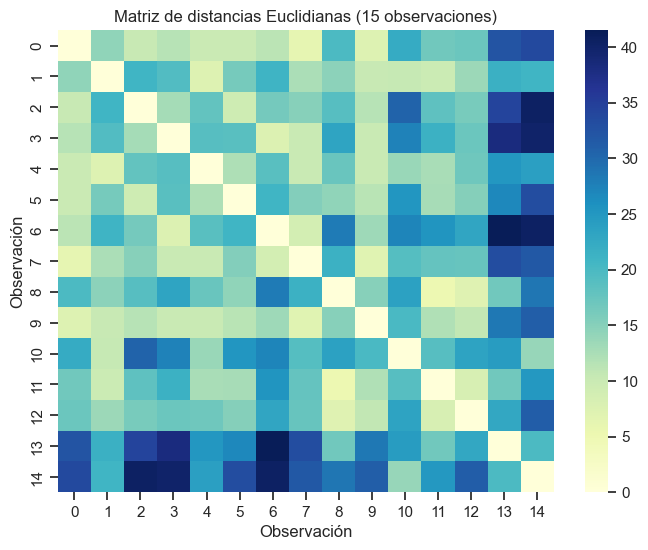

In [6]:
subset = df[['x1', 'x2', 'x3']].head(15).values
matriz_dist = squareform(pdist(subset, metric='euclidean'))

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_dist, cmap='YlGnBu')
plt.title('Matriz de distancias Euclidianas (15 observaciones)')
plt.xlabel('Observación')
plt.ylabel('Observación')
plt.show()

## 6. Fundamentos de PCA

El PCA busca nuevas variables (componentes principales) que:
1. Sean combinaciones lineales de las variables originales.
2. Capten la mayor varianza posible en orden descendente.
3. Sean ortogonales entre sí.

**Idea clave:** si pocas componentes explican gran parte de la varianza, podemos reducir dimensionalidad con mínima pérdida de información.

Antes de PCA se recomienda estandarizar variables para evitar que una escala domine el análisis.

In [7]:
features = ['x1', 'x2', 'x3']
X_features = df[features].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X_features)

pca = PCA()
X_pca = pca.fit_transform(X_std)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Varianza explicada': var_exp,
    'Varianza acumulada': var_acum
})

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.604607,0.604607
1,PC2,0.352627,0.957234
2,PC3,0.042766,1.000000


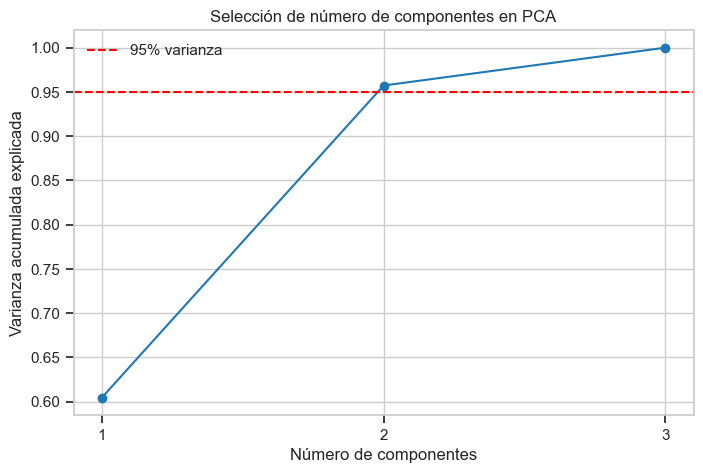

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% varianza')
plt.xticks(range(1, len(var_acum) + 1))
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Selección de número de componentes en PCA')
plt.legend()
plt.show()

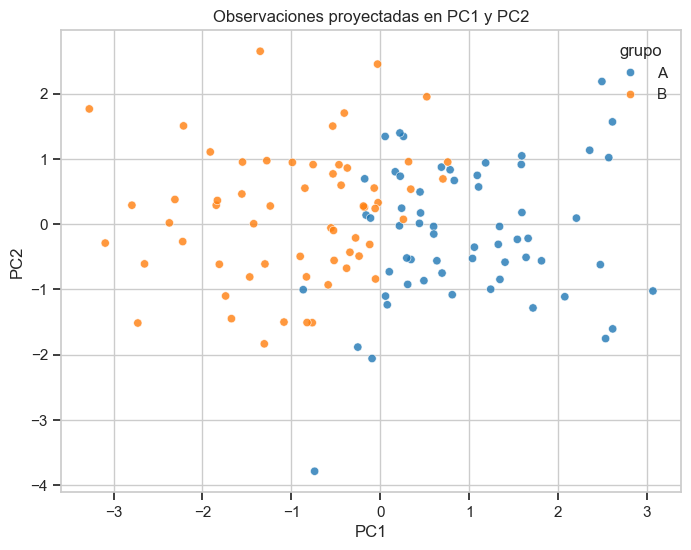

In [9]:
# Proyección en dos componentes para visualización
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_std)

df_pca = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_pca['grupo'] = df['grupo'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='grupo', alpha=0.8)
plt.title('Observaciones proyectadas en PC1 y PC2')
plt.show()

In [10]:
# Cargas (loadings): contribución de variables originales a cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(len(features))]
)
loadings

,PC1,PC2,PC3
x1,0.699374,-0.225509,-0.678249
x2,0.711985,0.136316,0.688837
x3,0.062883,0.964657,-0.255895


## 7. Caso práctico integrador

Se propone analizar qué observaciones están más alejadas del centro en el espacio original usando Mahalanobis,
y luego verificar su posición en el plano de PCA (PC1-PC2).

In [11]:
centro = X.mean(axis=0)
dist_centro_maha = np.array([mahalanobis(xi, centro, S_inv) for xi in X])

df_resultado = df_pca.copy()
df_resultado['dist_mahalanobis_centro'] = dist_centro_maha
df_resultado.sort_values('dist_mahalanobis_centro', ascending=False).head(10)

,PC1,PC2,grupo,dist_mahalanobis_centro
22,-0.738791,-3.783895,A,3.774776
89,2.492145,2.184761,A,3.750648
100,-0.847885,0.551331,B,3.114545
74,-3.272599,1.764996,B,2.976370
113,3.066098,-1.023319,A,2.932443
12,0.054496,1.343152,A,2.830628
59,2.610941,1.566708,A,2.799412
44,-1.350868,2.648043,B,2.753185
3,1.541093,-0.232756,A,2.751436
73,1.662306,-0.217339,A,2.656922


## 8. Ejercicios propuestos

1. Repite el análisis de distancias usando datos estandarizados y compara resultados.
2. Cambia la métrica de la matriz de distancias (Manhattan y Coseno) y comenta diferencias.
3. Encuentra el número mínimo de componentes que explica al menos 90% de varianza.
4. Interpreta qué variable aporta más a PC1 según la tabla de cargas.